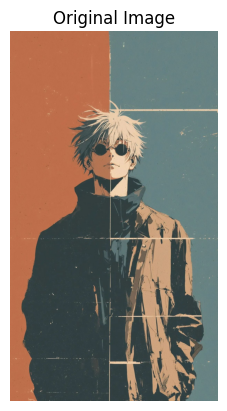

Image encrypted.


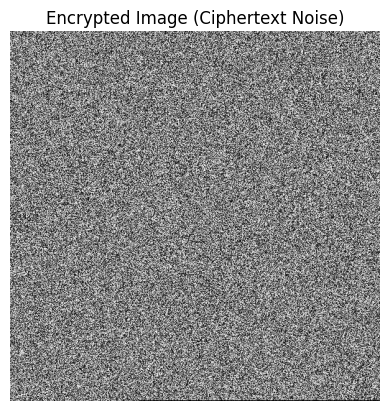

Image decrypted.


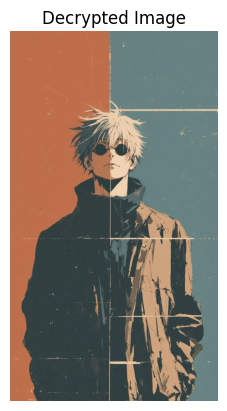

Decrypted image saved to decrypted_image.jpg


In [2]:
# Requires:
# pip install cryptography pillow matplotlib numpy

from cryptography.hazmat.primitives.ciphers.aead import AESGCM
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.hazmat.primitives.asymmetric import padding, rsa

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from io import BytesIO
import os

# ------------------ KEY GENERATION ------------------
def generate_keys():
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=2048
    )
    public_key = private_key.public_key()

    priv_pem = private_key.private_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PrivateFormat.PKCS8,
        encryption_algorithm=serialization.NoEncryption()
    )

    pub_pem = public_key.public_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PublicFormat.SubjectPublicKeyInfo
    )

    return priv_pem, pub_pem

# ------------------ HYBRID ENCRYPTION ------------------
def encrypt_image_hybrid(image_bytes: bytes, recipient_pub_pem: bytes):
    pub = serialization.load_pem_public_key(recipient_pub_pem)

    K = os.urandom(32)  # AES-256 key
    aesgcm = AESGCM(K)
    iv = os.urandom(12)
    C = aesgcm.encrypt(iv, image_bytes, None)

    EncK = pub.encrypt(
        K,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None,
        ),
    )

    digest = hashes.Hash(hashes.SHA256())
    digest.update(C)
    H = digest.finalize()

    return { "EncK": EncK, "iv": iv, "ciphertext": C, "hash": H }

# ------------------ HYBRID DECRYPTION ------------------
def decrypt_image_hybrid(package: dict, recipient_priv_pem: bytes):
    priv = serialization.load_pem_private_key(recipient_priv_pem, password=None)

    K = priv.decrypt(
        package["EncK"],
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None,
        ),
    )

    aesgcm = AESGCM(K)
    image_bytes = aesgcm.decrypt(package["iv"], package["ciphertext"], None)

    return image_bytes

# ------------------ DISPLAY UTILITIES ------------------
def display_image(title, image_bytes):
    img = Image.open(BytesIO(image_bytes))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

def cipher_to_noise_image(ciphertext: bytes):
    """Convert ciphertext to grayscale noise image"""
    data = np.frombuffer(ciphertext, dtype=np.uint8)

    # Make image square-ish
    size = int(np.ceil(np.sqrt(len(data))))
    padded = np.pad(data, (0, size*size - len(data)), mode='constant')

    img = padded.reshape((size, size))
    return img

def display_encrypted_image(ciphertext: bytes):
    noise_img = cipher_to_noise_image(ciphertext)
    plt.imshow(noise_img, cmap='gray')
    plt.title("Encrypted Image (Ciphertext Noise)")
    plt.axis("off")
    plt.show()

# ------------------ MAIN WORKFLOW ------------------
def main():
    # Load image
    input_path = "gojo_saturo.jpg"
    output_path = "decrypted_image.jpg"

    with open(input_path, "rb") as f:
        image_bytes = f.read()

    # Display original
    display_image("Original Image", image_bytes)

    # Generate RSA keys
    priv_pem, pub_pem = generate_keys()

    # Encrypt
    package = encrypt_image_hybrid(image_bytes, pub_pem)
    print("Image encrypted.")

    # Display encrypted image (as noise)
    display_encrypted_image(package["ciphertext"])

    # Decrypt
    decrypted_bytes = decrypt_image_hybrid(package, priv_pem)
    print("Image decrypted.")

    # Display decrypted
    display_image("Decrypted Image", decrypted_bytes)

    # Save decrypted
    with open(output_path, "wb") as f:
        f.write(decrypted_bytes)

    print(f"Decrypted image saved to {output_path}")

# ------------------ RUN ------------------
if __name__ == "__main__":
    main()
